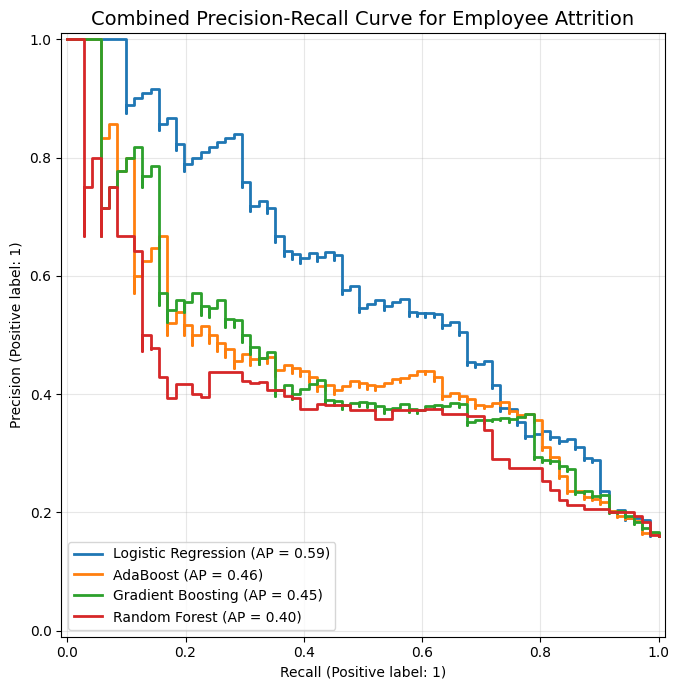


── Model Comparison Table ──
|                     |   Accuracy |   Precision |   Recall |   F1-Score |
|:--------------------|-----------:|------------:|---------:|-----------:|
| Logistic Regression |   0.789116 |    0.41129  | 0.71831  |   0.523077 |
| AdaBoost            |   0.836735 |    0.486486 | 0.253521 |   0.333333 |
| Gradient Boosting   |   0.845805 |    0.555556 | 0.211268 |   0.306122 |
| Random Forest       |   0.845805 |    0.6      | 0.126761 |   0.209302 |


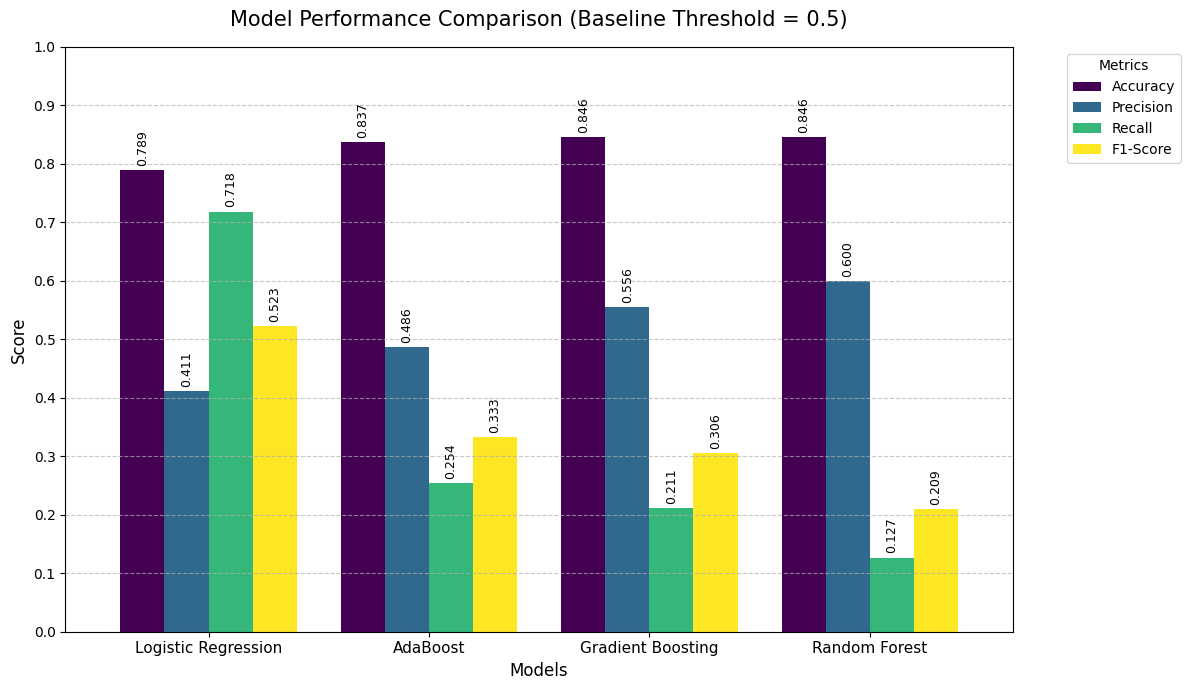

In [2]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    PrecisionRecallDisplay
)

from imblearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

# %%
# Load Data
df = pd.read_csv('../data/Processed_HR_Employee_Attrition.csv')
joblib.dump(df, '../df_original.pkl')

# Encode
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, drop_first=True)

# Split
X = df.drop(columns='Attrition')
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# %%
# Define Models Dictionary
# Using C=0.5 for Logistic Regression based on your previous GridSearchCV best param
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', solver='liblinear', C=0.5, max_iter=2000, random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42)
}

# Dictionaries to store results
results = {}
probas = {}

# Set up the combined Precision-Recall figure
fig_pr, ax_pr = plt.subplots(figsize=(10, 7))

# %%
# Train, Evaluate, and Plot PR Curve for each model
for name, model in models.items():
    
    # Create Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    # Fit Model
    pipeline.fit(X_train, y_train)
    
    # Get Probabilities and Predictions (using standard 0.5 threshold for baseline comparison)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = pipeline.predict(X_test) 
    
    # Store probabilities for later if needed
    probas[name] = y_proba
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store Metrics
    results[name] = [acc, prec, rec, f1]
    
    # Plot PR Curve on the shared axis
    PrecisionRecallDisplay.from_predictions(
        y_test, 
        y_proba, 
        name=name,
        ax=ax_pr,
        linewidth=2
    )

# %%
# 1. Finalize and Show Combined Precision-Recall Curve
ax_pr.set_title("Combined Precision-Recall Curve for Employee Attrition", fontsize=14)
ax_pr.grid(alpha=0.3)
ax_pr.legend(loc="lower left")
plt.tight_layout()
plt.show()

# %%
# 2. Generate and Display Table
# Convert results dictionary to a Pandas DataFrame
metrics_df = pd.DataFrame.from_dict(
    results, 
    orient='index', 
    columns=['Accuracy', 'Precision', 'Recall', 'F1-Score']
)

print("\n── Model Comparison Table ──")
# Displaying cleanly in the console/notebook
display(metrics_df) if 'display' in globals() else print(metrics_df.to_markdown())

# %%
# 3. Generate Grouped Bar Chart
# Plotting the DataFrame directly
ax_bar = metrics_df.plot(kind='bar', figsize=(12, 7), width=0.8, colormap='viridis')

plt.title('Model Performance Comparison (Baseline Threshold = 0.5)', fontsize=15, pad=15)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Models', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(np.arange(0, 1.1, 0.1))

# Add a grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Move legend outside the plot
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')

# Auto-label the bars with their specific values
for container in ax_bar.containers:
    ax_bar.bar_label(container, fmt='%.3f', padding=3, rotation=90, fontsize=9)

plt.tight_layout()
plt.show()